# Retinopatia Diabética

Datasets analisados:

- Aptos-2019
- EyePACS
- IDRiD
- Messidor-2

## Configuração de ambiente

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cria uma variável para armazenar o diretório base do projeto.
BASE_DIR = Path(r"D:\OIO+\DATASET_RETINA")

print("Pasta do projeto:", BASE_DIR)
print("Existe:", BASE_DIR.exists())

Pasta do projeto: D:\OIO+\DATASET_RETINA
Existe: True


## 1. Aptos-2019

### 1.1 Conjunto de treino.

In [ ]:
# Localizando o arquivo de metadados de treino do APTOS.
APTOS_METADATA = (
    BASE_DIR
    / "02.Catálogos"
    / "METADADOS"
    / "aptos_metadata.csv"
)

print(APTOS_METADATA)
print("Existe:", APTOS_METADATA.exists())

D:\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\aptos_metadata.csv
Existe: True


In [4]:
# Cria um dataframe a partir do arquivo CSV de metadados do APTOS.
aptos = pd.read_csv(APTOS_METADATA)

# Mostra as primeiras linhas do dataframe.
aptos.head()

,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,APTOS_2019,000c1434d8d7.png,retinopatia_diabetica,2,retinopatia_diabetica_moderada,train
1,2,APTOS_2019,001639a390f0.png,retinopatia_diabetica,4,retinopatia_diabetica_proliferativa,train
2,3,APTOS_2019,0024cdab0c1e.png,retinopatia_diabetica,1,retinopatia_diabetica_leve,train
3,4,APTOS_2019,002c21358ce6.png,retinopatia_diabetica,0,sem_retinopatia_diabetica,train
4,5,APTOS_2019,005b95c28852.png,retinopatia_diabetica,0,sem_retinopatia_diabetica,train


In [5]:
# Mostra informações sobre o dataframe.
aptos.columns.tolist()

['id_imagem',
 'dataset',
 'arquivo',
 'doenca',
 'codigo_diagnostico',
 'diagnostico',
 'conjunto']

#### 1.1.1 Estrutura geral do conjunto de treino.

In [6]:
print("Quantidade de registros:", len(aptos))
print("Quantidade de colunas:", len(aptos.columns))
print("Dimensão da tabela:", aptos.shape)

Quantidade de registros: 3662
Quantidade de colunas: 7
Dimensão da tabela: (3662, 7)


In [7]:
# Mostra a forma como a tabela está estruturada.
aptos.info()

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id_imagem           3662 non-null   int64
 1   dataset             3662 non-null   str  
 2   arquivo             3662 non-null   str  
 3   doenca              3662 non-null   str  
 4   codigo_diagnostico  3662 non-null   int64
 5   diagnostico         3662 non-null   str  
 6   conjunto            3662 non-null   str  
dtypes: int64(2), str(5)
memory usage: 200.4 KB


In [8]:
# Verifica se há valores nulos no dataframe.
aptos.isnull().sum()

id_imagem             0
dataset               0
arquivo               0
doenca                0
codigo_diagnostico    0
diagnostico           0
conjunto              0
dtype: int64

#### 1.1.2 Verificação de duplicatas e consistência dos registros.

In [ ]:
# Verifica se há linhas duplicadas no conjunto de treino.
print("Linhas duplicadas:", aptos.duplicated().sum())
print("IDs duplicados:", aptos["id_imagem"].duplicated().sum())
print("Arquivos duplicados:", aptos["arquivo"].duplicated().sum())

Linhas duplicadas: 0
IDs duplicados: 0
Arquivos duplicados: 0


In [10]:
print("Valores da coluna dataset:") 
print(aptos["dataset"].value_counts())

print("\nValores da coluna doença:")
print(aptos["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(aptos["conjunto"].value_counts())

Valores da coluna dataset:
dataset
APTOS_2019    3662
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    3662
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
train    3662
Name: count, dtype: int64


#### 1.1.3 Distribuição das classes.

In [11]:
# Mostra os códigos de diagnóstico e seus respectivos diagnósticos.
aptos[["codigo_diagnostico", "diagnostico"]].drop_duplicates().sort_values("codigo_diagnostico")

,codigo_diagnostico,diagnostico
3,0,sem_retinopatia_diabetica
2,1,retinopatia_diabetica_leve
0,2,retinopatia_diabetica_moderada
13,3,retinopatia_diabetica_grave
1,4,retinopatia_diabetica_proliferativa


In [12]:
# Checa a distribuição dos códigos de diagnóstico.
distribuicao = (
    aptos["codigo_diagnostico"].value_counts().sort_index()
)

distribuicao

codigo_diagnostico
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

In [13]:
percentual = (
    aptos["codigo_diagnostico"].value_counts(normalize=True).sort_index() * 100
)

percentual.round(2)

codigo_diagnostico
0    49.29
1    10.10
2    27.28
3     5.27
4     8.06
Name: proportion, dtype: float64

In [ ]:
tabela_classes = pd.DataFrame({
    "Quantidade": distribuicao,
    "Percentual": percentual.round(2)
})

tabela_classes

,Quantidade,Percentual
codigo_diagnostico,,
0,1805,49.29
1,370,10.10
2,999,27.28
3,193,5.27
4,295,8.06


#### Interpretação

O APTOS-2019 apresenta forte desbalanceamento entre as classes:

- Grau 0 - Sem retinopatia diabética: 1805 imagens (49,29%)
- Grau 1 - Retinopatia diabética leve: 370 imagens (10,10%)
- Grau 2 - Retinopatia diabética moderada: 999 imagens (27,28%)
- Grau 3 - Retinopatia diabética grave: 193 imagens (5,27%)
- Grau 4 - Retinopatia diabética proliferativa: 295 imagens (8,06%)

Sendo assim, a classe mais frequente é grau 0 (Sem retinopatia), enquanto a classe 3 (Retinopatia grave) possui menor participação no dataset.

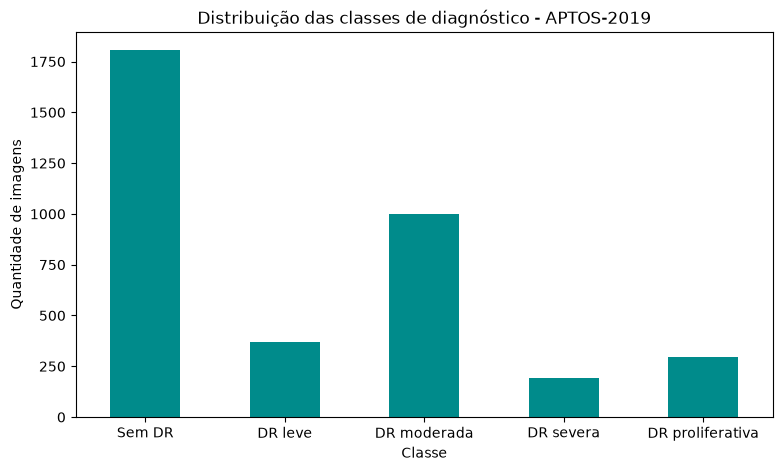

In [ ]:
# Cria um gráfico para mostrar a distribuição das classes de diagnóstico com seus respectivos nomes.
nomes_classes = {
    0: "Sem DR",
    1: "DR leve",
    2: "DR moderada",
    3: "DR severa",
    4: "DR proliferativa"
}

quantidades = distribuicao.copy()
quantidades.index = quantidades.index.map(nomes_classes)

quantidades.plot(kind="bar", figsize=(9, 5), color="darkcyan")

plt.title("Distribuição das classes de diagnóstico - APTOS-2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=0)
plt.show()

#### 1.1.4 Correspondência entre metadata e imagens.

In [ ]:
# Verifica se a pasta do APTOS existe.
APTOS_DIR = (
    BASE_DIR
    / "01.Originais"
    / "DR (RETINOPATIA DIABÉTICA)"
    / "APTOS-2019"
)

print("Pasta do APTOS:", APTOS_DIR)
print("Existe:", APTOS_DIR.exists())

Pasta do APTOS: D:\OIO+\DATASET_RETINA\01.Originais\DR (RETINOPATIA DIABÉTICA)\APTOS-2019
Existe: True


In [47]:
# Localiza todas as imagens PNG na pasta do APTOS.
TRAIN_IMAGES_DIR = APTOS_DIR / "train_images"

imagens_train = list(TRAIN_IMAGES_DIR.glob("*.png"))

print("Quantidade de imagens de treino:", len(imagens_train))
print("Quantidade de registros no metadados:", len(aptos))

Quantidade de imagens de treino: 3662
Quantidade de registros no metadados: 3662


In [48]:
# Compara os arquivos de imagens de treino com os registros do metadados.
arquivos_metadata_train = set(aptos["arquivo"])
arquivos_imagens_train = set([imagem.name for imagem in imagens_train])

sem_imagem_train = arquivos_metadata_train - arquivos_imagens_train
sem_metadata_train = arquivos_imagens_train - arquivos_metadata_train

print("Arquivos no metadados sem imagem correspondente:", len(sem_imagem_train))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata_train))

Arquivos no metadados sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 1.1.5 Análise técnica das imagens de treino.

In [ ]:
# Analisa uma imagem de treino para verificar seu formato e modo de cor.
from PIL import Image

imagem_exemplo = imagens_train[0]

with Image.open(imagem_exemplo) as img:
    print("Arquivo:", imagem_exemplo.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 000c1434d8d7.png
Formato: PNG
Modo de cor: RGB
Resolução: (3216, 2136)


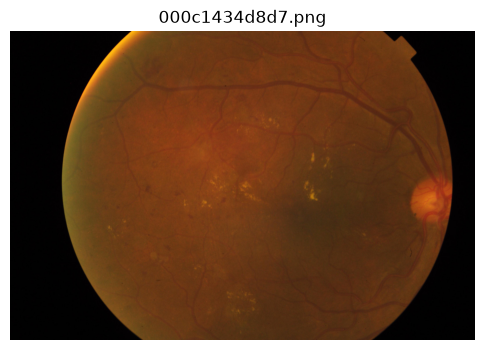

In [ ]:
# Mostra a imagem de exemplo.
with Image.open(imagem_exemplo) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo.name)
    plt.show()

In [ ]:
# Função para analisar tecnicamente o conjunto de imagens.
def analisar_imagens(lista_imagens):
    registros = []
    erros = []

    for caminho in lista_imagens:
        try:
            with Image.open(caminho) as img:

                # Força a leitura da imagem inteira.
                img.load()

                registros.append({
                    "arquivo": caminho.name,
                    "formato": img.format,
                    "modo_cor": img.mode,
                    "largura": img.width,
                    "altura": img.height,
                    "resolucao": f"{img.width}x{img.height}",
                    "tamanho_mb": caminho.stat().st_size / (1024 ** 2)
                })

        except Exception as erro:
            erros.append({
                "arquivo": caminho.name,
                "erro": str(erro)
            })

    dados = pd.DataFrame(registros)
    erros = pd.DataFrame(erros)

    return dados, erros

In [ ]:
# Analisa todas as imagens de treino.
analise_train, erros_train = analisar_imagens(imagens_train)

print("Imagens analisadas:", len(analise_train))
print("Erros de leitura:", len(erros_train))

analise_train.head()

Imagens analisadas: 3662
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,000c1434d8d7.png,PNG,RGB,3216,2136,3216x2136,3.069569
1,001639a390f0.png,PNG,RGB,3216,2136,3216x2136,2.156381
2,0024cdab0c1e.png,PNG,RGB,2416,1736,2416x1736,1.794979
3,002c21358ce6.png,PNG,RGB,1050,1050,1050x1050,0.930040
4,005b95c28852.png,PNG,RGB,2048,1536,2048x1536,1.735144


In [ ]:
# Mostra formatos e modos de cor encontrados nas imagens de treino.
print("Fomatos encontrados:")
print(analise_train["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_train["modo_cor"].value_counts())

Fomatos encontrados:
formato
PNG    3662
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    3662
Name: count, dtype: int64


In [57]:
print("Quantidade de resoluções diferentes:")
print(analise_train["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_train["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
17

10 resoluções mais frequentes:
resolucao
1050x1050    974
2416x1736    638
2588x1958    533
3216x2136    410
2048x1536    351
819x614      287
3388x2588    141
1504x1000     92
1844x1226     61
4288x2848     52
Name: count, dtype: int64


In [58]:
print("Estatísticas da largura:")
print(analise_train["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_train["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_train["tamanho_mb"].describe())

Estatísticas da largura:
count    3662.000000
mean     2015.176679
std       884.301940
min       474.000000
25%      1050.000000
50%      2144.000000
75%      2588.000000
max      4288.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    3662.000000
mean     1526.830147
std       542.663120
min       358.000000
25%      1050.000000
50%      1536.000000
75%      1958.000000
max      2848.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    3662.000000
mean        2.240448
std         1.680805
min         0.211465
25%         0.957485
50%         1.845313
75%         2.714966
max         7.318775
Name: tamanho_mb, dtype: float64


##### Interpretação

As 3.662 imagens do conjunto de treino foram lidas com sucesso, sem erros.

Todas as imagens estão no formato PNG e utilizam o modo de cor RGB.

Foram identificadas 17 resoluções diferentes, mostrando que o conjunto não possui dimensões padronizadas. A resolução mais frequente é 1050x1050, que corresponde há 974 imagens.

A largura das imagens varia de 474 a 4288 pixels, enquanto a altura varia de 358 a 2848 pixels. O tamanho dos arquivos varia aproximadamente entre 0,21 MB e 7,32 MB.

Essas diferenças de dimensão indicam heterogeneidade na resolução das imagens e devem ser consideradas em eventuais etapas futuras de pré-processamento.

#### 1.1.6 Qualidade e duplicatas das imagens.

In [ ]:
# Função para calcular o hash SHA-256 de um arquivo.
import hashlib

def calcular_hash(caminho):
    sha256 = hashlib.sha256()

    with open(caminho, "rb") as arquivo:
        for bloco in iter(lambda: arquivo.read(8192), b""):
            sha256.update(bloco)

    return sha256.hexdigest()

In [ ]:
# Cria um dataframe com os hashes das imagens de treino.
hashes_train = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_train],
    "hash": [calcular_hash(imagem) for imagem in imagens_train]
})

hashes_train.head()

,arquivo,hash
0,000c1434d8d7.png,3f34b577a7102dddea20d2aaed76028bcf724ddb82e923...
1,001639a390f0.png,9e4a10bcf0569bd7640ff3107601cb00c1147c44de5d3e...
2,0024cdab0c1e.png,ef0bda2c21f3dbe839b4e5168fa7e52afe61e6923a56fd...
3,002c21358ce6.png,c18a236541ae3d3ddbf8cf3eae991b4ff28446c5313b3d...
4,005b95c28852.png,4af20410946f8730d1a9c13361a0b4604c5934c325890b...


In [75]:
# Identifica imagens duplicadas em treino com base no hash.
duplicados_train = hashes_train[
    hashes_train["hash"].duplicated(keep=False)
].sort_values("hash")

print("Imagens pertencentes a grupos duplicados:", len(duplicados_train))
print("Hashes duplicados:", duplicados_train["hash"].nunique())

Imagens pertencentes a grupos duplicados: 251
Hashes duplicados: 123


### 1.2 Conjunto de teste.

#### 1.2.1 Estrutura geral do conjunto de teste

In [25]:
# Localizando o arquivo de metadados de teste do APTOS.
APTOS_TEST_METADATA = (
    BASE_DIR
    / "02.Catálogos"
    / "METADADOS"
    / "Teste"
    / "aptos_test_metadata.csv"
)

print(APTOS_TEST_METADATA)
print("Existe:", APTOS_TEST_METADATA.exists())

D:\OIO+\DATASET_RETINA\02.Catálogos\METADADOS\Teste\aptos_test_metadata.csv
Existe: True


In [ ]:
# Cria o dataframe de a partir dos metadados de teste do APTOS.
aptos_test = pd.read_csv(APTOS_TEST_METADATA)

aptos_test.head()

,id_imagem,dataset,arquivo,doenca,codigo_diagnostico,diagnostico,conjunto
0,1,APTOS_2019,0005cfc8afb6.png,retinopatia_diabetica,NaN,nao_disponivel,test
1,2,APTOS_2019,003f0afdcd15.png,retinopatia_diabetica,NaN,nao_disponivel,test
2,3,APTOS_2019,006efc72b638.png,retinopatia_diabetica,NaN,nao_disponivel,test
3,4,APTOS_2019,00836aaacf06.png,retinopatia_diabetica,NaN,nao_disponivel,test
4,5,APTOS_2019,009245722fa4.png,retinopatia_diabetica,NaN,nao_disponivel,test


In [27]:
print("Quantidade de registros:", len(aptos_test))
print("Quantidade de colunas:", len(aptos_test.columns))
print("Dimensão da tabela:", aptos_test.shape)

Quantidade de registros: 1928
Quantidade de colunas: 7
Dimensão da tabela: (1928, 7)


In [28]:
# Mostra a estrutura do dataframe de teste.
aptos_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1928 entries, 0 to 1927
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_imagem           1928 non-null   int64  
 1   dataset             1928 non-null   str    
 2   arquivo             1928 non-null   str    
 3   doenca              1928 non-null   str    
 4   codigo_diagnostico  0 non-null      float64
 5   diagnostico         1928 non-null   str    
 6   conjunto            1928 non-null   str    
dtypes: float64(1), int64(1), str(5)
memory usage: 105.6 KB


In [30]:
# Verifica valores ausentes no conjunto de teste.
aptos_test.isnull().sum()

id_imagem                0
dataset                  0
arquivo                  0
doenca                   0
codigo_diagnostico    1928
diagnostico              0
conjunto                 0
dtype: int64

#### 1.2.2 Verificação de duplicatas e consistência dos registros.

In [33]:
# Checa se há linhas duplicadas no conjunto de teste.
print("Linhas duplicadas no conjunto de teste:", aptos_test.duplicated().sum())
print("IDs duplicados no conjunto de teste:", aptos_test["id_imagem"].duplicated().sum())
print("Arquivos duplicados no conjunto de teste:", aptos_test["arquivo"].duplicated().sum())

Linhas duplicadas no conjunto de teste: 0
IDs duplicados no conjunto de teste: 0
Arquivos duplicados no conjunto de teste: 0


In [37]:
print("Valores da coluna dataset:")
print(aptos_test["dataset"].value_counts())

print("\nValores da coluna doença:")
print(aptos_test["doenca"].value_counts())

print("\nValores da coluna conjunto:")
print(aptos_test["conjunto"].value_counts())

print("\nCódigos de diagnóstico ausentes:")
print(aptos_test["codigo_diagnostico"].isna().sum())

Valores da coluna dataset:
dataset
APTOS_2019    1928
Name: count, dtype: int64

Valores da coluna doença:
doenca
retinopatia_diabetica    1928
Name: count, dtype: int64

Valores da coluna conjunto:
conjunto
test    1928
Name: count, dtype: int64

Códigos de diagnóstico ausentes:
1928


#### 1.2.3 Disponibilidade dos diagnósticos.

In [44]:
# Verifica a disponibilidade dos diagnósticos no conjunto de teste.

print(
    "Códigos de diagnóstico ausentes:",
    aptos_test["codigo_diagnostico"].isna().sum()
)

print("\nValores da coluna diagnóstico:")
print(
    aptos_test["diagnostico"].value_counts(dropna=False)
)

Códigos de diagnóstico ausentes: 1928

Valores da coluna diagnóstico:
diagnostico
nao_disponivel    1928
Name: count, dtype: int64


O conjunto de teste do APTOS-2019 não possui os diagnósticos reais disponíveis nos arquivos utilizados nesta análise. Por esse motivo, não é possível realizar a distribuição das classes para o conjunto de teste.

#### 1.2.4 Correspondência entre metadata e imagens.

In [38]:
# Localiza a pasta de imagens de teste.

TEST_IMAGES_DIR = APTOS_DIR / "test_images"

imagens_test = list(TEST_IMAGES_DIR.glob("*.png"))

print("Quantidade de imagens de teste:", len(imagens_test))
print("Quantidade de registros no metadados:", len(aptos_test))

Quantidade de imagens de teste: 1928
Quantidade de registros no metadados: 1928


In [39]:
# Compara os arquivos de imagens de teste com os registros do metadados.
arquivos_metadata = set(aptos_test["arquivo"])
arquivos_imagens = set([imagem.name for imagem in imagens_test])

sem_imagem = arquivos_metadata - arquivos_imagens
sem_metadata = arquivos_imagens - arquivos_metadata

print("Arquivos no metadados sem imagem correspondente:", len(sem_imagem))
print("Arquivos com imagem sem registro correspondente:", len(sem_metadata))

Arquivos no metadados sem imagem correspondente: 0
Arquivos com imagem sem registro correspondente: 0


#### 1.2.5 Análise técnica das imagens de teste.

In [63]:
# Analisa uma imagem de teste para verificar seu formato e modo de cor.
imagem_exemplo_test = imagens_test[0]

with Image.open(imagem_exemplo_test) as img:
    print("Arquivo:", imagem_exemplo_test.name)
    print("Formato:", img.format)
    print("Modo de cor:", img.mode)
    print("Resolução:", img.size)

Arquivo: 0005cfc8afb6.png
Formato: PNG
Modo de cor: RGB
Resolução: (640, 480)


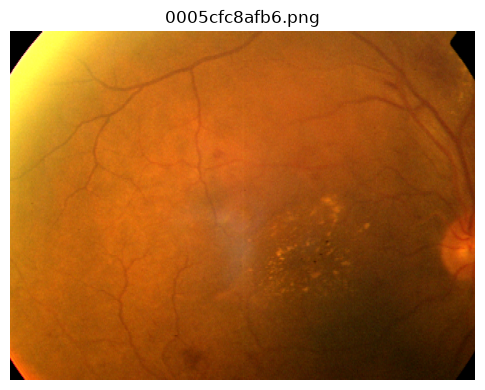

In [64]:
# Mostra a imagem de teste.
with Image.open(imagem_exemplo_test) as img:
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(imagem_exemplo_test.name)
    plt.show()

In [68]:
# Reutiliza a função de análise para o conjunto de imagens de teste.
analise_test, erros_test = analisar_imagens(imagens_test)

print("Imagens analisadas:", len(analise_test))
print("Erros de leitura:", len(erros_test))

analise_test.head()

Imagens analisadas: 1928
Erros de leitura: 0


,arquivo,formato,modo_cor,largura,altura,resolucao,tamanho_mb
0,0005cfc8afb6.png,PNG,RGB,640,480,640x480,0.225072
1,003f0afdcd15.png,PNG,RGB,640,480,640x480,0.202460
2,006efc72b638.png,PNG,RGB,640,480,640x480,0.193110
3,00836aaacf06.png,PNG,RGB,640,480,640x480,0.223653
4,009245722fa4.png,PNG,RGB,640,480,640x480,0.235420


In [ ]:
# Mostra formatos e modos de cor encontrados nas imagens de teste.
print("Formatos encontrados:")
print(analise_test["formato"].value_counts())

print("\nModos de cor encontrados:")
print(analise_test["modo_cor"].value_counts())

Formatos encontrados:
formato
PNG    1928
Name: count, dtype: int64

Modos de cor encontrados:
modo_cor
RGB    1928
Name: count, dtype: int64


In [70]:
# Mostra estatísticas das resoluções encontradas nas imagens de teste.
print("Quantidade de resoluções diferentes:")
print(analise_test["resolucao"].nunique())

print("\n10 resoluções mais frequentes:")
print(analise_test["resolucao"].value_counts().head(10))

Quantidade de resoluções diferentes:
12

10 resoluções mais frequentes:
resolucao
640x480      1403
2416x1736     225
2588x1958     134
1050x1050      69
819x614        45
2048x1536      28
2896x1944      11
2592x1944       6
768x576         2
1467x1110       2
Name: count, dtype: int64


In [71]:
print("Estatísticas da largura:")
print(analise_test["largura"].describe())

print("\nEstatísticas da altura:")
print(analise_test["altura"].describe())

print("\nEstatísticas do tamanho dos arquivos (MB):")
print(analise_test["tamanho_mb"].describe())

Estatísticas da largura:
count    1928.000000
mean     1043.535788
std       740.511732
min       640.000000
25%       640.000000
50%       640.000000
75%       819.000000
max      2896.000000
Name: largura, dtype: float64

Estatísticas da altura:
count    1928.000000
mean      783.152490
std       541.308109
min       480.000000
25%       480.000000
50%       480.000000
75%       614.000000
max      1958.000000
Name: altura, dtype: float64

Estatísticas do tamanho dos arquivos (MB):
count    1928.000000
mean        0.798230
std         1.231747
min         0.174269
25%         0.209105
50%         0.219121
75%         0.408817
max         5.541361
Name: tamanho_mb, dtype: float64


##### Interpretação

As 1.928 imagens do conjunto de teste foram lidas com sucesso, sem erros.

Todas as imagens estão no formato PNG e utilizam o modo de cor RGB.

Foram identificadas 12 resoluções diferentes. A resolução predominante é 640x480, presente em 1.403 imagens, correspondendo à maior parte do conjunto de teste.

A largura das imagens varia de 640 a 2896 pixels, enquanto a altura varia de 480 a 1958 pixels. O tamanho médio dos arquivos é de aproximadamente 0,80 MB.

Assim como no conjunto de treino, existem diferentes resoluções no conjunto de teste. Entretanto, o teste apresenta forte predominância de imagens com resolução 640x480.

#### 1.2.6 Qualidade e duplicatas das imagens.

In [78]:
# Calcula o hash de todas as imagens de teste.

hashes_test = pd.DataFrame({
    "arquivo": [imagem.name for imagem in imagens_test],
    "hash": [calcular_hash(imagem) for imagem in imagens_test]
})

hashes_test.head()

,arquivo,hash
0,0005cfc8afb6.png,e001c14dcb9c61b90d1fe48f72c2ca86b333c426902d68...
1,003f0afdcd15.png,7a2788507137cdfffe20f42903fa755db13c87fbf48645...
2,006efc72b638.png,5f82049508338b1e86adea0991c314614ea96e213505d9...
3,00836aaacf06.png,84e34dbfc3cb7e028401b308c1cbeabfa55beb82313c65...
4,009245722fa4.png,e38547568df0c3c2480e5168fb4ba9cbe4bf9e9f7a105e...


In [79]:
# Identifica imagens duplicadas no teste com base no hash.

duplicados_test = hashes_test[
    hashes_test["hash"].duplicated(keep=False)
].sort_values("hash")

print(
    "Imagens pertencentes a grupos duplicados:",
    len(duplicados_test)
)

print(
    "Hashes duplicados:",
    duplicados_test["hash"].nunique()
)

Imagens pertencentes a grupos duplicados: 12
Hashes duplicados: 6
